# Import Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import scanpy as sc 
import pygenelab as pgl
import decoupler as dc
import pandas as pd
from scipy.stats import rankdata
import matplotlib.pyplot as plt

# Util Functions

In [3]:
def cliffs_delta(x, y):
    """
    calculate cliff's delta between two groups
    """

    # cliffs_delta
    # api:
    # cliffs_delta(
    #     x=om6_scores,
    #     y=om9_scores,
    # )

    # remove missing values
    x = pd.Series(x).dropna().to_numpy()
    y = pd.Series(y).dropna().to_numpy()

    nx = len(x)
    ny = len(y)

    # return nan if either group is empty
    if nx == 0 or ny == 0:
        return float("nan")

    # rank all values together
    ranks = rankdata(list(x) + list(y))

    # get ranks for first group
    x_ranks = ranks[:nx]

    # mann-whitney u for first group
    u = x_ranks.sum() - nx * (nx + 1) / 2

    # convert u to cliff's delta
    delta = (2 * u / (nx * ny)) - 1

    return delta

In [4]:
def save_df_table_image(
    df,
    output_path=None,
    index=False,
    round_digits=4,
    font_size=10,
    row_height=0.5,
    min_col_width=0.08,
    max_col_width=0.45
):
    """
    create a dataframe table image and optionally save it
    """

    # save_df_table_image
    # api:
    # fig = save_df_table_image(
    #     df=cliffs_df,
    #     output_path="Output/cliffs_table.png",
    # )

    # copy df so original is not changed
    df_to_show = df.copy()

    # round numeric columns
    numeric_cols = df_to_show.select_dtypes(include="number").columns
    df_to_show[numeric_cols] = df_to_show[numeric_cols].round(round_digits)

    # include index if requested
    if index:
        df_to_show = df_to_show.reset_index()

    # convert everything to string for display
    df_display = df_to_show.astype(str)

    # get table shape
    nrows, ncols = df_display.shape

    # compute column widths from max text length
    col_lengths = []
    for col in df_display.columns:
        max_cell_len = df_display[col].map(len).max()
        header_len = len(str(col))
        col_lengths.append(max(max_cell_len, header_len))

    total_len = sum(col_lengths)

    # normalized widths
    col_widths = []
    for length in col_lengths:
        width = length / total_len
        width = max(min_col_width, width)
        width = min(max_col_width, width)
        col_widths.append(width)

    # renormalize so widths sum to about 1
    width_sum = sum(col_widths)
    col_widths = [w / width_sum for w in col_widths]

    # figure size
    fig_width = max(12, sum(col_lengths) * 0.18)
    fig_height = max(2.5, (nrows + 1) * row_height)

    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    ax.axis("off")

    # create table
    table = ax.table(
        cellText=df_display.values,
        colLabels=df_display.columns,
        cellLoc="center",
        loc="center",
        bbox=[0, 0, 1, 1]
    )

    # base style
    table.auto_set_font_size(False)
    table.set_fontsize(font_size)
    table.scale(1, 1.4)

    # style cells
    for (row, col), cell in table.get_celld().items():
        # set per-column widths
        cell.set_width(col_widths[col])

        # header row
        if row == 0:
            cell.set_text_props(weight="bold")

        # left align first column for long pathway names
        if col == 0 and row > 0:
            cell.get_text().set_ha("left")
            cell.PAD = 0.01

    plt.tight_layout()

    # save only if path is provided
    if output_path is not None:
        fig.savefig(output_path, dpi=300, bbox_inches="tight")

    return fig

In [5]:
def calculate_score_cliffs_delta(
    adata,
    score_col,
    group_col="sample",
    group1="OM6",
    group2="OM9",
    dropna=True
):
    """
    calculate cliff's delta for one obs score column between two groups
    """

    # calculate_obs_score_cliffs_delta
    # api:
    # result_df, group_score_df = calculate_obs_score_cliffs_delta(
    #     adata=adata,
    #     score_col="GOBP_PYRUVATE_METABOLIC_PROCESS",
    #     group_col="sample",
    #     group1="OM6",
    #     group2="OM9",
    # )

    # check required columns
    if group_col not in adata.obs.columns:
        raise ValueError(f"{group_col} not found in adata.obs")

    if score_col not in adata.obs.columns:
        raise ValueError(f"{score_col} not found in adata.obs")

    # prepare cell-level score dataframe
    group_score_df = adata.obs[[group_col, score_col]].copy()

    # remove missing values
    if dropna:
        group_score_df = group_score_df.dropna(subset=[group_col, score_col])

    # add pathway name
    group_score_df["pathway"] = score_col

    # get group scores
    group1_scores = group_score_df.loc[
        group_score_df[group_col] == group1,
        score_col
    ]

    group2_scores = group_score_df.loc[
        group_score_df[group_col] == group2,
        score_col
    ]

    # calculate cliff's delta
    delta = cliffs_delta(
        x=group1_scores,
        y=group2_scores
    )

    # decide direction
    if delta > 0:
        higher_group = group1
    elif delta < 0:
        higher_group = group2
    else:
        higher_group = "similar"

    # store result
    result = {
        "score_col": score_col,

        f"{group1}_count": group1_scores.dropna().shape[0],
        f"{group2}_count": group2_scores.dropna().shape[0],

        f"{group1}_mean": group1_scores.mean(),
        f"{group2}_mean": group2_scores.mean(),

        f"{group1}_median": group1_scores.median(),
        f"{group2}_median": group2_scores.median(),

        f"{group1}_std": group1_scores.std(),
        f"{group2}_std": group2_scores.std(),

        f"{group1}_min": group1_scores.min(),
        f"{group2}_min": group2_scores.min(),

        f"{group1}_max": group1_scores.max(),
        f"{group2}_max": group2_scores.max(),

        "mean_difference": group1_scores.mean() - group2_scores.mean(),
        "median_difference": group1_scores.median() - group2_scores.median(),

        "cliffs_delta": delta,
        "abs_cliffs_delta": abs(delta),
        "higher_group": higher_group
    }

    # convert result to dataframe
    result_df = pd.DataFrame([result])

    return result_df, group_score_df

# Get Data

In [6]:
# # load complete mice dataset
# MICE_DATASET_PATH = (
#     r"/ocean/projects/cis240075p/asachan/datasets/TA_muscle/ERCC1_KO_mice/"
#     r"integrated_samples/objects/adata_harmony_celloracle_compatible_v2.h5ad"
# )
# mice_dataset =  sc.read_h5ad(MICE_DATASET_PATH)

# # load female fastiix and fastiib
# mice_dataset_female = mice_dataset[mice_dataset.obs["sex"] == "F"].copy()
# mice_dataset_female_iix_iib = mice_dataset_female[(mice_dataset_female.obs["C_scANVI"] == "Fast IIX") | 
#                                                   (mice_dataset_female.obs["C_scANVI"] == "Fast IIB")].copy()

In [7]:
# female metacells

# load female metacell dataset
FEMALE_METACELL_PATH = r"/ocean/projects/cis240075p/asachan/datasets/TA_muscle/ERCC1_KO_mice/integrated_samples/objects/seacells_F_FastIIB_FastIIX_harmonyv2.h5ad" 
female_metacell_dataset = sc.read_h5ad(FEMALE_METACELL_PATH)

# create condition column
female_metacell_dataset.obs["condition"] = (
    female_metacell_dataset.obs["y"]
    .apply(lambda x: "WT" if x == 0 else "KO")
).copy()

In [8]:
# specify which dataset to use
adata = female_metacell_dataset.copy()

# Get Geneset

In [9]:
# pathway gene dictionary

# custom atrophy genes
custom_atrophy_genes = [
    "UBB", "UBC", "FBXO32", "TRIM63", "MDM2", "FBXO30", "CAMK2B", "TIE1",
    "PSMA1", "PSMA2", "PSMA3", "PSMA4", "PSMA5", "PSMA6", "PSMA7",
    "PSMB1", "PSMB2", "PSMB3", "PSMB4", "FBXO21", "FBXO31", "NEDD4",
    "UBE2B", "UBE2G1", "UBE2J1", "CTSL", "CTSV", "BNIP3", "DEPP1",
    "GABARAPL1", "MAP1LC3", "RETREG1", "SQSTM1", "CAPN1", "CAPN2",
    "ATF4", "FOXO1", "FOXO3A", "HDAC9", "RUNX1", "AMPD3", "CHRNA1",
    "CDKN1A"
]

# convert human-style uppercase symbols to mouse-style title case
custom_atrophy_genes_mouse = [
    gene.capitalize()
    for gene in custom_atrophy_genes
]

# atrophy pathway name
atrophy_pathway = "Atrophy_Pathway_(PMID 31325479)"

# create custom atrophy decoupler dataframe
atrophy_pathway_genes = pd.DataFrame({
    "source": atrophy_pathway,
    "target": custom_atrophy_genes_mouse
})

# mice all pathways path
MICE_ALL_PATHWAYS = (
    "/ocean/projects/cis240075p/asachan/datasets/gene_sets/mouse/"
    "msigdb.v2024.1.Mm.symbols.gmt"
)

# marked metabolic pathways
metabolic_pathways = [
    "HALLMARK_FATTY_ACID_METABOLISM",
    "HALLMARK_XENOBIOTIC_METABOLISM",
    "REACTOME_PYRUVATE_METABOLISM",
    "REACTOME_PHOSPHOLIPID_METABOLISM",
    "REACTOME_GLYCOGEN_METABOLISM",
    "REACTOME_GLYCOSAMINOGLYCAN_METABOLISM",
    "WP_PURINE_METABOLISM"
]

# dictionary to store all pathway gene dataframes
pathway_gene_dict = {}

# add custom atrophy pathway
pathway_gene_dict[atrophy_pathway] = atrophy_pathway_genes

# add metabolic pathways
for pathway in metabolic_pathways:

    # load one pathway from gmt file
    pathway_genes = pgl.convert_gmt_to_decoupler_format(
        MICE_ALL_PATHWAYS,
        include_pathways=[pathway],
        gene_origin="mice"
    )

    # store pathway dataframe
    pathway_gene_dict[pathway] = pathway_genes

# check dictionary keys
pathway_gene_dict.keys()

dict_keys(['Atrophy_Pathway_(PMID 31325479)', 'HALLMARK_FATTY_ACID_METABOLISM', 'HALLMARK_XENOBIOTIC_METABOLISM', 'REACTOME_PYRUVATE_METABOLISM', 'REACTOME_PHOSPHOLIPID_METABOLISM', 'REACTOME_GLYCOGEN_METABOLISM', 'REACTOME_GLYCOSAMINOGLYCAN_METABOLISM', 'WP_PURINE_METABOLISM'])

In [13]:
pathway_gene_dict["HALLMARK_FATTY_ACID_METABOLISM"].head()

,source,target
0,HALLMARK_FATTY_ACID_METABOLISM,Aadat
1,HALLMARK_FATTY_ACID_METABOLISM,Acaa1a
2,HALLMARK_FATTY_ACID_METABOLISM,Acaa2
3,HALLMARK_FATTY_ACID_METABOLISM,Acadl
4,HALLMARK_FATTY_ACID_METABOLISM,Acadm


# Calculate Scores

# Calculate And Save Cliffs Delta

In [15]:
%%time

# calculate cliff's delta for all pathways

cliffs_delta_dict = {}
cliffs_delta_results = []
failed_pathways = {}

group_col = "condition"
group1 = "WT"
group2 = "KO"

for pathway, pathway_genes in pathway_gene_dict.items():

    print(f"processing: {pathway}")

    # calculate aucell only if score is not already in obs
    if pathway not in adata.obs.columns:

        try:
            dc.mt.aucell(
                adata,
                pathway_genes,
                raw=False,
                verbose=False
            )

            # check aucell score exists
            if "score_aucell" not in adata.obsm:
                raise ValueError("score_aucell not found in adata.obsm")

            if pathway not in adata.obsm["score_aucell"].columns:
                raise ValueError(f"{pathway} not found in score_aucell columns")

            # store score in obs
            adata.obs[pathway] = adata.obsm["score_aucell"][pathway].copy()

        except Exception as e:
            failed_pathways[pathway] = str(e)
            print(f"skipped {pathway}: {e}")
            continue

    # calculate cliff's delta
    try:
        df, group_score_df = calculate_score_cliffs_delta(
            adata,
            score_col=pathway,
            group_col=group_col,
            group1=group1,
            group2=group2
        )

        # store pathway result
        cliffs_delta_dict[pathway] = df.copy()
        cliffs_delta_results.append(df.copy())

    except Exception as e:
        failed_pathways[pathway] = str(e)
        print(f"failed cliffs delta for {pathway}: {e}")
        continue

# combine all results into one dataframe
cliffs_delta_df = pd.concat(
    cliffs_delta_results,
    ignore_index=True
)

# sort strongest effects first
cliffs_delta_df = cliffs_delta_df.sort_values(
    "abs_cliffs_delta",
    ascending=False
).reset_index(drop=True)

cliffs_delta_df

processing: Atrophy_Pathway_(PMID 31325479)
processing: HALLMARK_FATTY_ACID_METABOLISM
processing: HALLMARK_XENOBIOTIC_METABOLISM
processing: REACTOME_PYRUVATE_METABOLISM
skipped REACTOME_PYRUVATE_METABOLISM: No sources with more than tmin=5 targets after
     filtering by shared features in mat.
     Make sure mat and net have shared target features or
     reduce the number assigned to tmin
processing: REACTOME_PHOSPHOLIPID_METABOLISM
processing: REACTOME_GLYCOGEN_METABOLISM
processing: REACTOME_GLYCOSAMINOGLYCAN_METABOLISM
processing: WP_PURINE_METABOLISM
CPU times: user 33.3 ms, sys: 2.97 ms, total: 36.2 ms
Wall time: 35.2 ms


,score_col,WT_count,KO_count,WT_mean,KO_mean,WT_median,KO_median,WT_std,KO_std,WT_min,KO_min,WT_max,KO_max,mean_difference,median_difference,cliffs_delta,abs_cliffs_delta,higher_group
0,HALLMARK_XENOBIOTIC_METABOLISM,232,219,0.030102,0.044786,0.026510,0.046895,0.016359,0.019257,0.003380,0.008450,0.065272,0.079425,-0.014684,-0.020384,-0.441407,0.441407,KO
1,REACTOME_GLYCOGEN_METABOLISM,232,219,0.463154,0.519094,0.464626,0.529252,0.087145,0.052693,0.257143,0.382313,0.616327,0.624490,-0.055940,-0.064626,-0.376949,0.376949,KO
2,REACTOME_PHOSPHOLIPID_METABOLISM,232,219,0.031749,0.037679,0.035182,0.038832,0.014878,0.012377,0.000000,0.008467,0.059854,0.060730,-0.005930,-0.003650,-0.217367,0.217367,KO
3,HALLMARK_FATTY_ACID_METABOLISM,232,219,0.100940,0.105929,0.100000,0.105263,0.012377,0.017290,0.071805,0.052256,0.144361,0.155263,-0.004989,-0.005263,-0.214907,0.214907,KO
4,WP_PURINE_METABOLISM,232,219,0.150012,0.154948,0.151687,0.156827,0.016866,0.015289,0.108065,0.105430,0.185293,0.182393,-0.004936,-0.005140,-0.177157,0.177157,KO
5,Atrophy_Pathway_(PMID 31325479),232,219,0.235706,0.263214,0.251422,0.265074,0.098385,0.051979,0.000000,0.124005,0.447099,0.389078,-0.027508,-0.013652,-0.146611,0.146611,KO
6,REACTOME_GLYCOSAMINOGLYCAN_METABOLISM,232,219,0.026400,0.026341,0.025838,0.025641,0.002362,0.002858,0.022682,0.021696,0.037475,0.049507,0.000059,0.000197,0.066171,0.066171,WT


PosixPath('Output/Cliffs_Delta_SVG.svg')

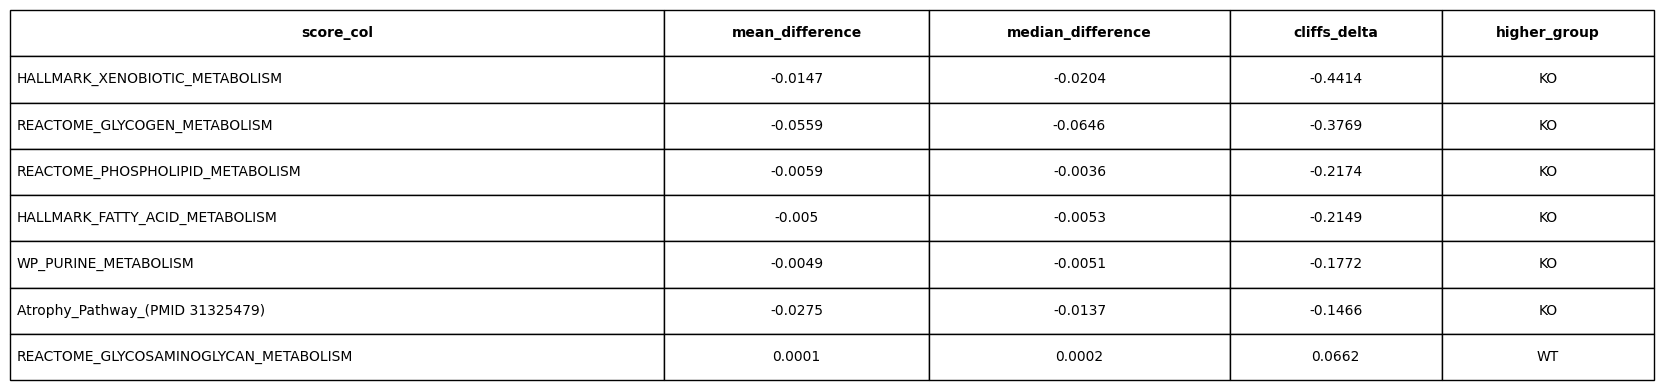

In [20]:
plot_df = cliffs_delta_df[["score_col", "mean_difference", "median_difference", "cliffs_delta", "higher_group"]]
fig_cliffs_delta = save_df_table_image(plot_df)
pgl.save_fig_as_png(fig_cliffs_delta, "Output/Cliffs_Delta_PNG.png")
pgl.save_editable_svg(fig_cliffs_delta, "Output/Cliffs_Delta_SVG.svg")

# Develop And Save Plot